# Hyperparameter Black-Scholes
## Lambda

In [ ]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# Sweep
import itertools

### Colab Setup

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")

Cloning into '/content/fys5429'...
remote: Enumerating objects: 559, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (71/71), done.
^Cceiving objects:  89% (498/559), 23.45 MiB | 46.87 MiB/s


FileNotFoundError: [Errno 2] No such file or directory: '/content/fys5429/code/notebooks'

### Paths

In [ ]:
# Pathways
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")

../data/generated/bs_collocation.parquet
../plots/eda


### Global parameters

In [ ]:
# Answer to the universe and everything
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adding torch backends
torch.backends.cudnn.benchmark = True

# Option Physics (Analytical Benchmarks)
K = 100.0
r = 0.05
sigma = 0.20
T_max = 1.0
S_max = 300.0

# NN
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 128

# Training
LEARNING_RATE = 0.0005
PRINT_ROWS = 20

# PINN Loss Weights
LAMBDA_PDE = 5.0
LAMBDA_IC = 10.0
LAMBDA_BC = 5.0

# Epochs and sweeps
LAMBDA_PDE_VALUES = [5.0, 10.0, 20.0]
LAMBDA_IC_VALUES  = [5.0, 10.0, 20.0]
LAMBDA_BC_FIXED   = 5.0
SWEEP_EPOCHS      = 5000

Using device: cuda


### Black-Scholes PINN Class

In [ ]:
class BSPINN(nn.Module):
    def __init__(self, hidden_layers=HIDDEN_LAYERS, neurons_per_layer=NEURONS_PER_LAYER,
                 S_scale=None, tau_scale=None):
        super(BSPINN, self).__init__()

        self.S_scale = S_scale or S_max
        self.tau_scale = tau_scale or T_max

        layers = [nn.Linear(2, neurons_per_layer), nn.Softplus()]
        for _ in range(hidden_layers):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.Softplus())
        layers.append(nn.Linear(neurons_per_layer, 1))

        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, S, tau):
        S_norm = S / self.S_scale
        tau_norm = tau / self.tau_scale
        x = torch.cat([S_norm, tau_norm], dim=1)
        return self.net(x)

### Reading Data

In [ ]:
# Check if data exists and has the right S range, otherwise regenerate
if data_path.exists():
    df_all = pd.read_parquet(data_path)
    s_range = df_all['S'].max()
    if s_range < S_max * 0.9:
        print(f"Existing data has S_max={s_range:.0f}, expected ~{S_max:.0f}. Regenerating...")
        data_path.unlink()

if not data_path.exists():
    print(f"Generating collocation data with S_max={S_max}, T_max={T_max}...")

    N_INTERIOR = 2000
    N_BOUNDARY = 500

    S_interior = torch.rand(N_INTERIOR, 1) * S_max
    tau_interior = torch.rand(N_INTERIOR, 1) * T_max

    S_ic_gen = torch.rand(N_BOUNDARY, 1) * S_max
    tau_ic_gen = torch.zeros(N_BOUNDARY, 1)

    S_bc_gen = torch.zeros(N_BOUNDARY, 1)
    tau_bc_gen = torch.rand(N_BOUNDARY, 1) * T_max

    df_all = pd.concat([
        pd.DataFrame({'S': S_interior.numpy().flatten(),
                       'tau': tau_interior.numpy().flatten(),
                       'point_type': 'interior'}),
        pd.DataFrame({'S': S_ic_gen.numpy().flatten(),
                       'tau': tau_ic_gen.numpy().flatten(),
                       'point_type': 'initial_condition'}),
        pd.DataFrame({'S': S_bc_gen.numpy().flatten(),
                       'tau': tau_bc_gen.numpy().flatten(),
                       'point_type': 'boundary_condition'}),
    ], ignore_index=True)

    data_path.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_parquet(data_path)
    print(f"Saved to {data_path}")
else:
    print(f"Loaded existing data from {data_path} (S_max={df_all['S'].max():.0f})")

# Extract tensors
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S_tensor, tau_tensor

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, tau_ic = extract_tensors(df_ic)

df_bc = df_all[df_all['point_type'] == 'boundary_condition']
S_bc, tau_bc = extract_tensors(df_bc)

print(f"Interior points: {len(S_in)}")
print(f"IC points:       {len(S_ic)}")
print(f"BC points:       {len(S_bc)}")

Loaded existing data from ../data/generated/bs_collocation.parquet (S_max=300)
Interior points: 2000
IC points:       500
BC points:       500


### Training

In [ ]:
def train_pinn(lambda_pde, lambda_ic, lambda_bc, epochs, lr=0.001, hidden_layers=3, neurons=128, verbose=False):

    model = BSPINN(hidden_layers, neurons).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    grad_ones = torch.ones_like(S_in)

    history = {'epoch': [], 'pde': [], 'ic': [], 'bc': [], 'total': []}
    sample_interval = max(1, epochs // 100)

    for epoch in range(epochs):

        optimizer.zero_grad()

        V_pred = model(S_in, tau_in)

        V_S = torch.autograd.grad(V_pred, S_in, grad_outputs=grad_ones, create_graph=True)[0]
        V_tau = torch.autograd.grad(V_pred, tau_in, grad_outputs=grad_ones, create_graph=True)[0]
        V_SS = torch.autograd.grad(V_S, S_in, grad_outputs=grad_ones, create_graph=True)[0]

        pde_residual = V_tau - (0.5 * sigma**2 * S_in**2 * V_SS + r * S_in * V_S - r * V_pred)
        loss_pde = torch.mean(pde_residual**2)

        V_ic_pred = model(S_ic, tau_ic)
        V_ic_true = torch.relu(S_ic - K)
        loss_ic = torch.mean((V_ic_pred - V_ic_true)**2)

        V_bc_pred = model(S_bc, tau_bc)
        loss_bc = torch.mean((V_bc_pred - 0.0)**2)

        loss = lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        if epoch % sample_interval == 0 or epoch == epochs - 1:
            history['epoch'].append(epoch)
            history['pde'].append(loss_pde.item())
            history['ic'].append(loss_ic.item())
            history['bc'].append(loss_bc.item())
            history['total'].append(loss.item())

        if epoch > 500 and epoch % sample_interval == 0:
            if len(history['total']) >= 2 and abs(history['total'][-1] - history['total'][-2]) / (history['total'][-2] + 1e-12) < 1e-5:
                break

    return {
        'model': model,
        'history': history,
        'final_pde': loss_pde.item(),
        'final_ic': loss_ic.item(),
        'final_bc': loss_bc.item(),
        'final_total': loss.item()
    }

### Lambda Sweep

In [ ]:
sweep_results = []
start_time = time.time()
total_runs = len(LAMBDA_PDE_VALUES) * len(LAMBDA_IC_VALUES)

header = f"{'#':>3} | {'λ_PDE':>6} {'λ_IC':>6} | {'PDE Loss':>12} {'IC Loss':>12} {'BC Loss':>12} | {'Time':>6} {'ETA':>8}"
print(header)
print("─" * len(header))

for i, (lam_pde, lam_ic) in enumerate(itertools.product(LAMBDA_PDE_VALUES, LAMBDA_IC_VALUES)):

    run_start = time.time()
    result = train_pinn(lam_pde, lam_ic, LAMBDA_BC_FIXED, SWEEP_EPOCHS)

    result['lambda_pde'] = lam_pde
    result['lambda_ic'] = lam_ic
    result['lambda_bc'] = LAMBDA_BC_FIXED
    sweep_results.append(result)

    run_sec = time.time() - run_start
    total_elapsed = time.time() - start_time
    eta = (total_elapsed / (i + 1)) * (total_runs - i - 1)

    print(f"{i+1:>3} | {lam_pde:>6.1f} {lam_ic:>6.1f} | "
          f"{result['final_pde']:>12.6f} {result['final_ic']:>12.6f} {result['final_bc']:>12.6f} | "
          f"{run_sec:>5.0f}s {eta:>6.0f}s")

elapsed = time.time() - start_time
print("─" * len(header))
print(f"Sweep complete: {len(sweep_results)} runs in {int(elapsed//60)}m {int(elapsed%60):02d}s")

  # |  λ_PDE   λ_IC |     PDE Loss      IC Loss      BC Loss |   Time      ETA
──────────────────────────────────────────────────────────────────────────────
  1 |    5.0    5.0 |     0.133388     0.232745     0.000539 |    67s    538s
  2 |    5.0   10.0 |     0.236501     0.225960     0.000417 |    66s    467s
  3 |    5.0   20.0 |     1.724362     0.315610     0.006386 |    66s    399s
  4 |   10.0    5.0 |     0.092061     0.435697     0.001379 |    65s    330s
  5 |   10.0   10.0 |     0.200431     0.349515     0.001193 |    66s    264s
  6 |   10.0   20.0 |     0.712473     0.400068     0.001691 |    65s    198s
  7 |   20.0    5.0 |     0.069784     0.685147     0.000277 |    65s    131s
  8 |   20.0   10.0 |     0.054020     0.291134     0.000212 |    66s     66s
  9 |   20.0   20.0 |     0.139490     0.320944     0.001437 |    65s      0s
──────────────────────────────────────────────────────────────────────────────
Sweep complete: 9 runs in 9m 50s


### Results

In [ ]:
# Having the sweeps in a dataframe
df_sweep = pd.DataFrame([{
    'lambda_pde': r['lambda_pde'],
    'lambda_ic': r['lambda_ic'],
    'pde_loss': r['final_pde'],
    'ic_loss': r['final_ic'],
    'bc_loss': r['final_bc'],
    'total_loss': r['final_total'],
} for r in sweep_results])

# Sorting the values by PDE Loss
df_sweep = df_sweep.sort_values('pde_loss')

# Printing out to the console
print(df_sweep.to_string(index=False))

 lambda_pde  lambda_ic  pde_loss  ic_loss  bc_loss  total_loss
       20.0       10.0  0.054020 0.291134 0.000212    3.992800
       20.0        5.0  0.069784 0.685147 0.000277    4.822808
       10.0        5.0  0.092061 0.435697 0.001379    3.105992
        5.0        5.0  0.133388 0.232745 0.000539    1.833362
       20.0       20.0  0.139490 0.320944 0.001437    9.215864
       10.0       10.0  0.200431 0.349515 0.001193    5.505431
        5.0       10.0  0.236501 0.225960 0.000417    3.444195
       10.0       20.0  0.712473 0.400068 0.001691   15.134548
        5.0       20.0  1.724362 0.315610 0.006386   14.965940


### Heatmaps

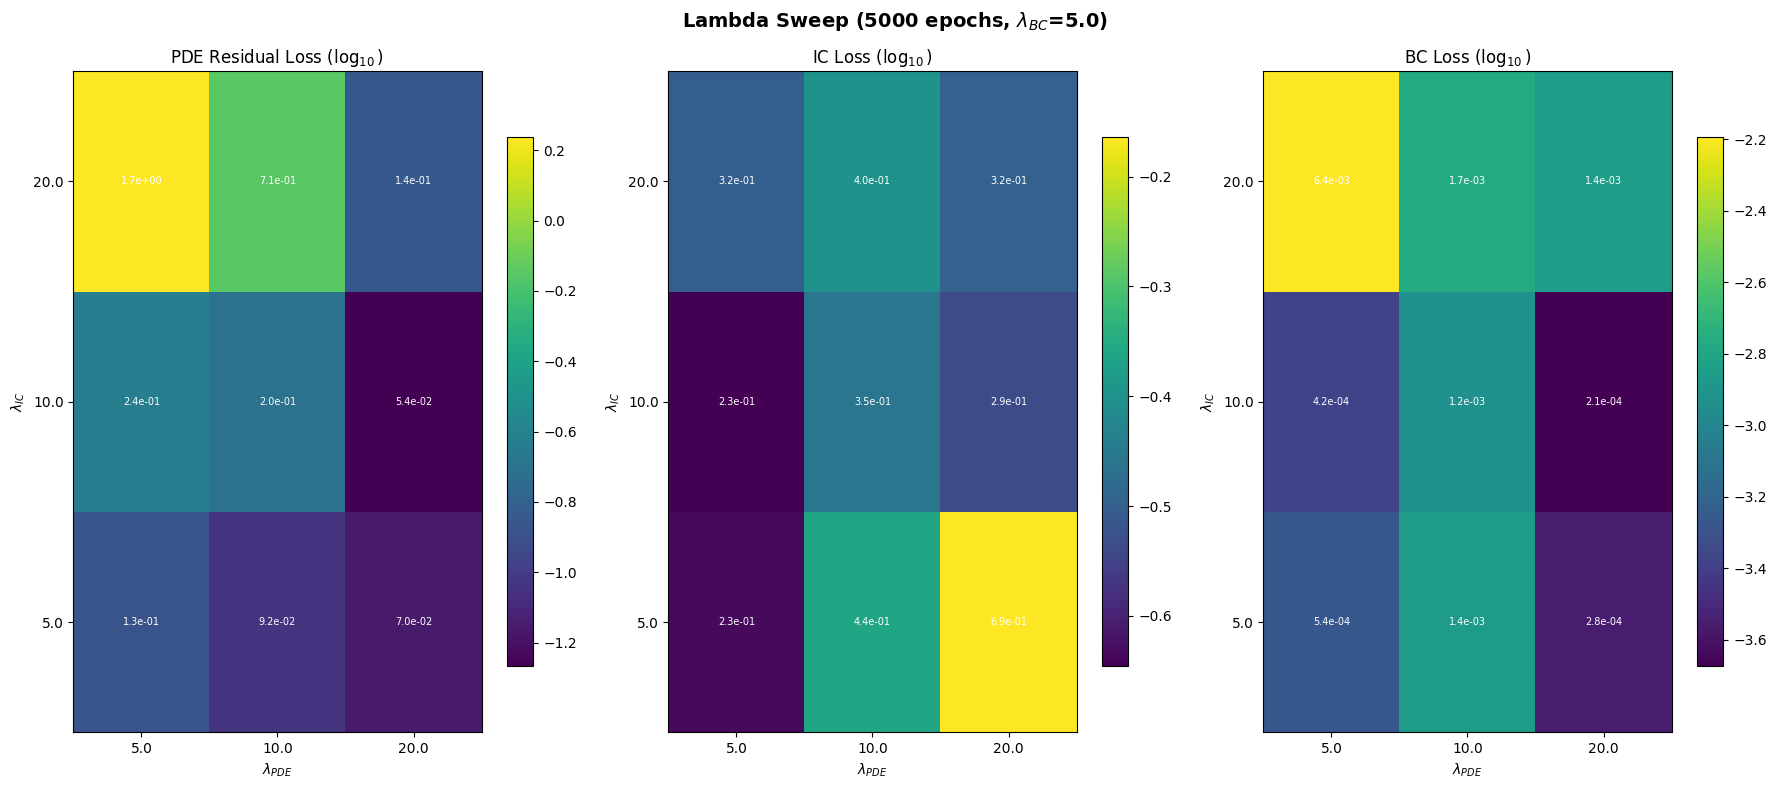

In [ ]:
# Initiating the heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 8))


for ax, metric, title in zip(axes,
  ['pde_loss', 'ic_loss', 'bc_loss'],
  ['PDE Residual Loss', 'IC Loss', 'BC Loss']):
  pivot = df_sweep.pivot_table(index='lambda_ic', columns='lambda_pde', values=metric)
  log_vals = np.log10(pivot.values)
  im = ax.imshow(log_vals, cmap='viridis', aspect='auto', origin='lower')
  ax.set_xticks(range(len(LAMBDA_PDE_VALUES)))
  ax.set_xticklabels(LAMBDA_PDE_VALUES)
  ax.set_yticks(range(len(LAMBDA_IC_VALUES)))
  ax.set_yticklabels(LAMBDA_IC_VALUES)
  ax.set_xlabel('$\\lambda_{PDE}$')
  ax.set_ylabel('$\\lambda_{IC}$')
  ax.set_title(f'{title} ($\\log_{{10}}$)')
  fig.colorbar(im, ax=ax, shrink=0.8)
  for i in range(len(LAMBDA_IC_VALUES)):
      for j in range(len(LAMBDA_PDE_VALUES)):
          ax.text(j, i, f'{pivot.values[i, j]:.1e}',
                  ha='center', va='center', fontsize=7, color='white')
plt.suptitle(f'Lambda Sweep ({SWEEP_EPOCHS} epochs, $\\lambda_{{BC}}$={LAMBDA_BC_FIXED})',
           fontweight='bold', fontsize=14)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_dir / "hyper_bs_heatmap.pdf", bbox_inches="tight")
plt.show()

### Ranked by PDE Loss

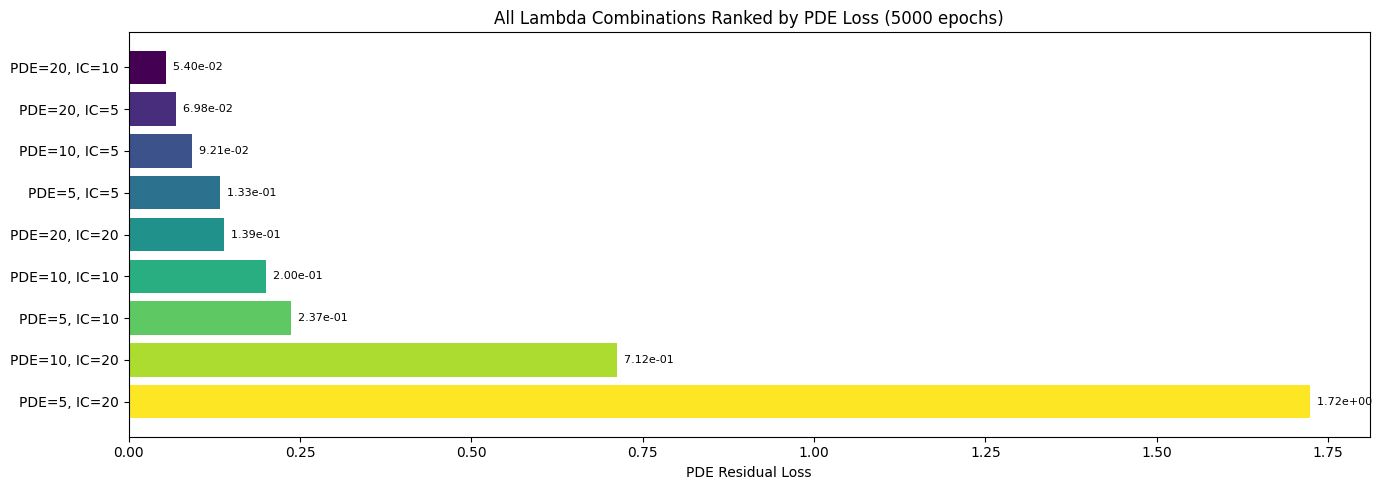

In [ ]:
df_ranked = df_sweep.sort_values('pde_loss').reset_index(drop=True)
labels = [f"PDE={r.lambda_pde:.0f}, IC={r.lambda_ic:.0f}"
          for _, r in df_ranked.iterrows()]

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ranked)))
bars = ax.barh(range(len(df_ranked)), df_ranked['pde_loss'], color=colors)
ax.set_yticks(range(len(df_ranked)))
ax.set_yticklabels(labels)
ax.set_xlabel('PDE Residual Loss')
ax.set_title(f'All Lambda Combinations Ranked by PDE Loss ({SWEEP_EPOCHS} epochs)')
ax.invert_yaxis()

for i, v in enumerate(df_ranked['pde_loss']):
    ax.text(v, i, f'  {v:.2e}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(out_dir / "hyper_bs_ranked.pdf", bbox_inches="tight")
plt.show()

### Top 3 Loss Curves

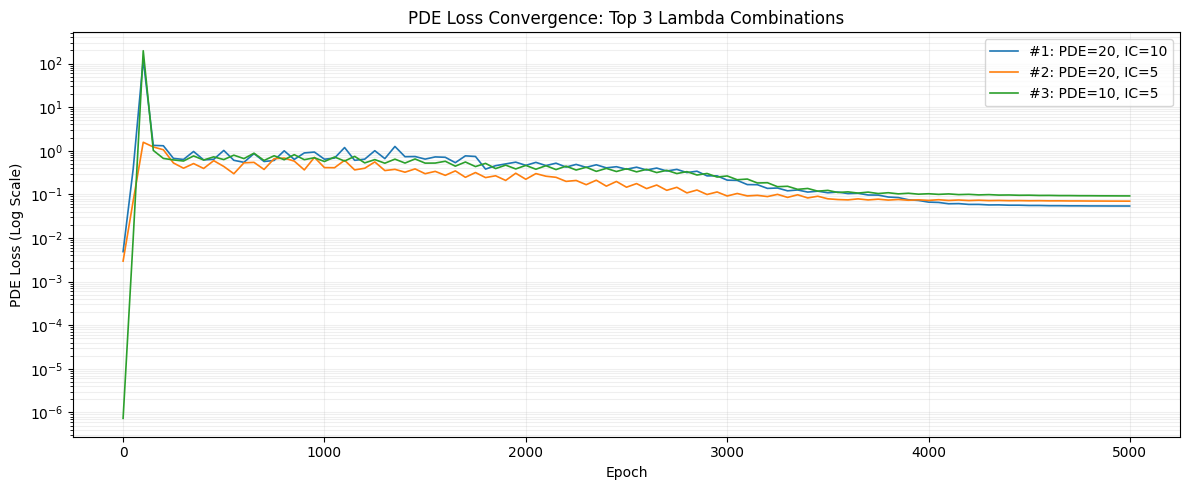

In [ ]:
df_ranked = df_sweep.sort_values('pde_loss').reset_index(drop=True)
top_3_indices = df_ranked.head(3).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))

for rank, idx in enumerate(top_3_indices):
    r = sweep_results[idx] if idx < len(sweep_results) else None
    for orig in sweep_results:
        if (orig['lambda_pde'] == df_ranked.loc[idx, 'lambda_pde'] and
            orig['lambda_ic'] == df_ranked.loc[idx, 'lambda_ic']):
            r = orig
            break

    label = f"#{rank+1}: PDE={r['lambda_pde']:.0f}, IC={r['lambda_ic']:.0f}"
    ax.plot(r['history']['epoch'], r['history']['pde'], label=label, lw=1.2)

ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('PDE Loss (Log Scale)')
ax.set_title('PDE Loss Convergence: Top 3 Lambda Combinations')
ax.legend()
ax.grid(True, which='both', ls='-', alpha=0.2)
plt.tight_layout()
plt.savefig(out_dir / "hyper_bs_top3_curves.pdf", bbox_inches="tight")
plt.show()

In [ ]:
### Download the plots again from Colab

In [ ]:
if IN_COLAB:
    from google.colab import drive
    from pathlib import Path
    import shutil

    drive.mount('/content/drive')

    plots_dir = Path(repo_dir) / "code" / "plots" / "eda"
    drive_dest = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/")
    drive_dest.mkdir(parents=True, exist_ok=True)

    for name in ["hyper_bs_heatmap.pdf", "hyper_bs_ranked.pdf", "hyper_bs_top3_curves.pdf"]:
        src = plots_dir / name
        if src.exists():
            shutil.copy2(src, drive_dest / name)
            print(f"Copied: {name} -> {drive_dest / name}")
        else:
            print(f"Not found: {src}")

    print(f"\nFiles saved to Google Drive: MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/")
else:
    print(f"PDFs saved locally to: {out_dir.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied: hyper_bs_heatmap.pdf -> /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/hyper_bs_heatmap.pdf
Copied: hyper_bs_ranked.pdf -> /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/hyper_bs_ranked.pdf
Copied: hyper_bs_top3_curves.pdf -> /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/hyper_bs_top3_curves.pdf

Files saved to Google Drive: MyDrive/GITHUB-COLAB/fys5429/code/plots/eda/
